# Project : AI Job Salary Prediction Using KNN Regression

# Problem Statement: 
- Companies and job seekers want to know the expected salary for AI jobs. Salary can depend on factors like experience, remote work, job description, and benefits.
- The goal of this project is to use KNN Regression to predict the salary of an AI job based on these factors.
- The dataset contains 15,000 job records and 19 columns.

# Target Variable
- salary_usd

# Input Features
- years_experience
- remote_ratio
- job_description_length
- benefits_score

# Business Objective
- Predict expected job salary.
- Understand how job-related factors affect salary.
- Help job seekers estimate their expected salary.
- Build and evaluate a KNN Regression model.

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df=pd.read_csv("/Users/nidagallusandeep/Downloads/ai_job_dataset.csv")

In [8]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [ ]:
df.tail()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name,remote_type
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics,Hybrid
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics,On-site
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations,Hybrid
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics,On-site
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,2024-07-18,2024-08-10,2492,7.6,AI Innovations,Hybrid


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

# Numerical Columns
- salary_usd 
- remote_ratio 
- years_experience
- job_description_length 
- benefits_score

# Categorical Columns
- job_id
- job_title
- salary_currency
- experience_level
- employment_type
- company_location
- company_size
- employee_residence
- required_skills
- education_required
- industry
- posting_date
- application_deadline
- company_name

In [10]:
df.shape

(15000, 19)

In [70]:
df.size

300000

In [11]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

# Check Missing Values

In [61]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
remote_type               0
dtype: int64

# Percentage of missing values:

In [62]:
(df.isnull().sum() / len(df)) * 100

job_id                    0.0
job_title                 0.0
salary_usd                0.0
salary_currency           0.0
experience_level          0.0
employment_type           0.0
company_location          0.0
company_size              0.0
employee_residence        0.0
remote_ratio              0.0
required_skills           0.0
education_required        0.0
years_experience          0.0
industry                  0.0
posting_date              0.0
application_deadline      0.0
job_description_length    0.0
benefits_score            0.0
company_name              0.0
remote_type               0.0
dtype: float64

# Check Duplicates

In [63]:
df.duplicated().sum()

np.int64(0)

# If duplicates exist:

In [64]:
df.drop_duplicates(inplace=True)

# Basic Statistical Analysis

In [65]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


# For categorical columns:

In [66]:
df.describe(include="object")

,job_id,job_title,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,required_skills,education_required,industry,posting_date,application_deadline,company_name,remote_type
count,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,15000,20,3,4,4,20,3,20,13663,4,15,486,543,16,3
top,AI00001,Machine Learning Researcher,USD,MI,FT,Germany,S,Sweden,"Python, TensorFlow, PyTorch",Bachelor,Retail,2024-07-05,2025-01-05,TechCorp Inc,On-site
freq,1,808,11957,3781,3812,814,5007,790,17,3789,1063,51,47,980,5075


# Check Unique Values

In [67]:
df.nunique()

job_id                    15000
job_title                    20
salary_usd                14315
salary_currency               3
experience_level              4
employment_type               4
company_location             20
company_size                  3
employee_residence           20
remote_ratio                  3
required_skills           13663
education_required            4
years_experience             20
industry                     15
posting_date                486
application_deadline        543
job_description_length     2000
benefits_score               51
company_name                 16
remote_type                   3
dtype: int64

In [68]:
df["job_title"].nunique()

20

In [69]:
df["company_location"].nunique()

20

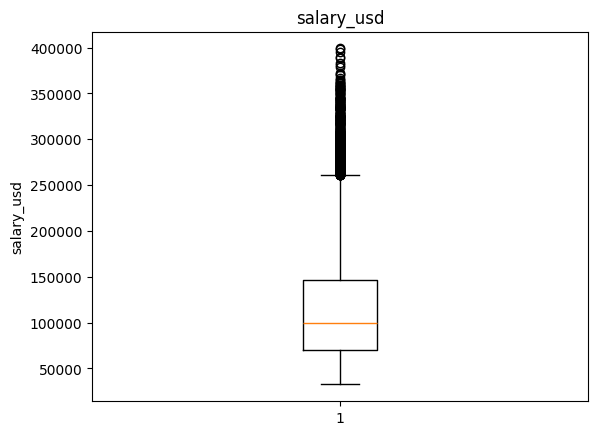

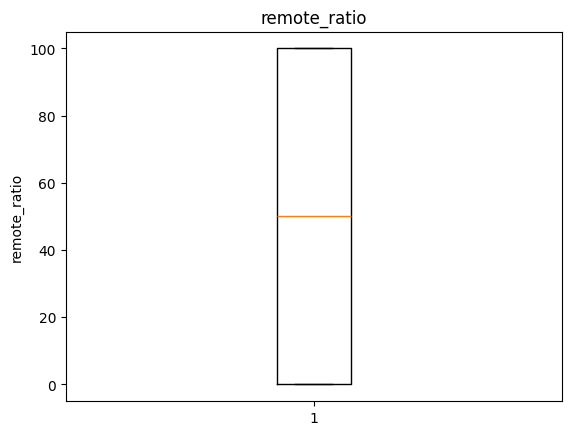

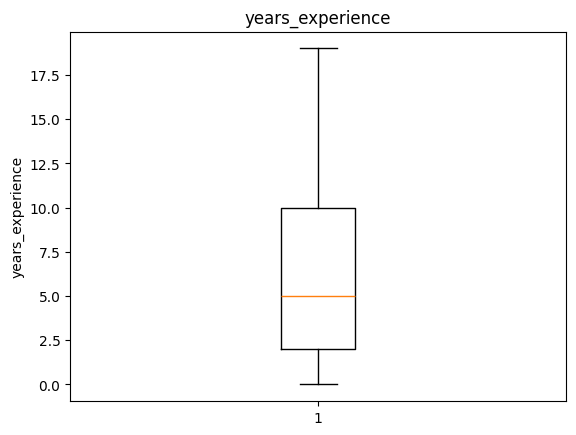

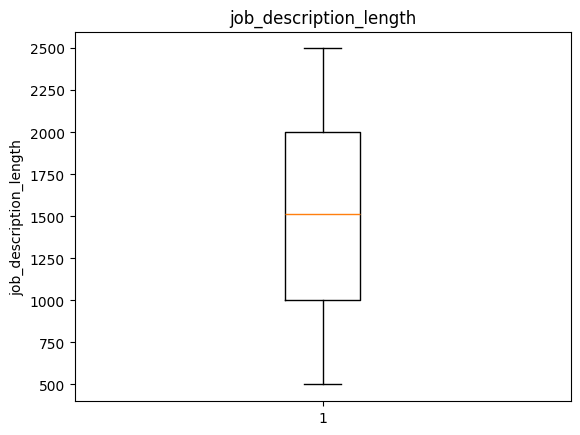

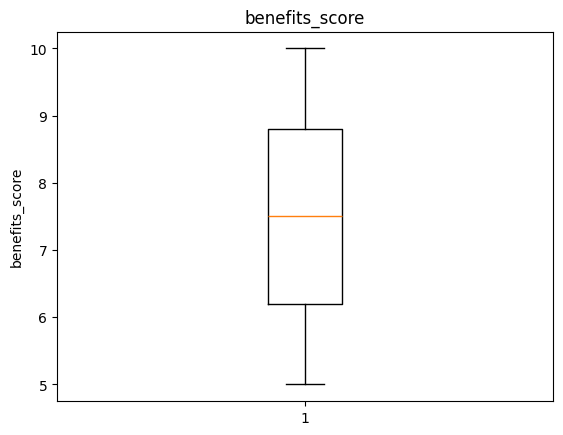

In [72]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    plt.boxplot(df[col])
    plt.title(col)
    plt.ylabel(col)
    plt.show()

# BUSINESS QUESTION 1

**1.Which AI/ML job roles are most in demand?**

In [19]:
job_demand = df["job_title"].value_counts()
job_demand.head(10)

job_title
Machine Learning Researcher    808
AI Software Engineer           784
Autonomous Systems Engineer    777
Machine Learning Engineer      772
AI Architect                   771
Head of AI                     765
NLP Engineer                   762
Robotics Engineer              759
Data Analyst                   759
AI Research Scientist          756
Name: count, dtype: int64

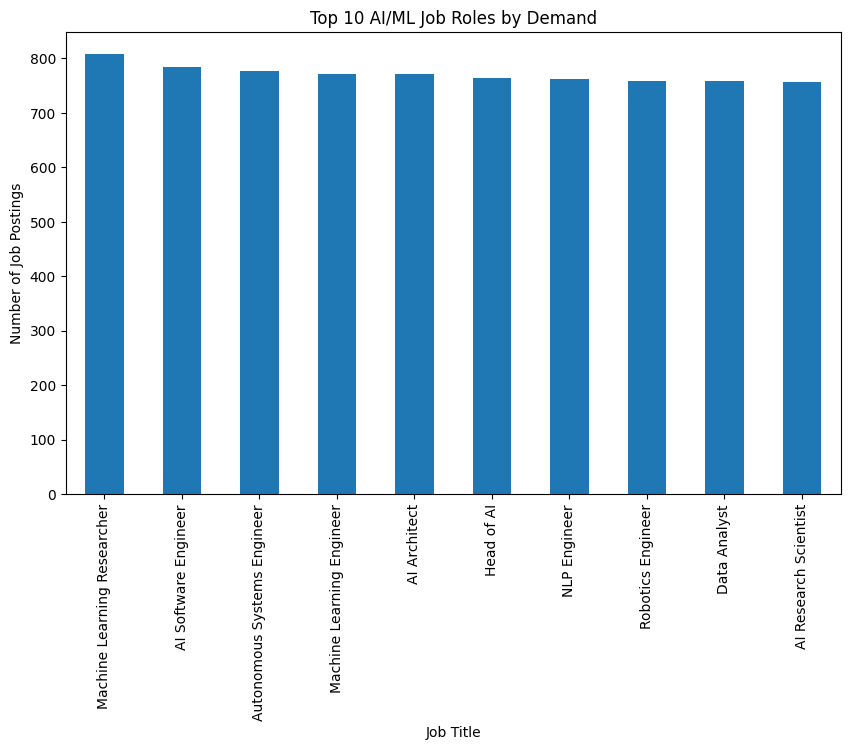

In [21]:
plt.figure(figsize=(10,6))
job_demand.head(10).plot(kind="bar")
plt.title("Top 10 AI/ML Job Roles by Demand")
plt.xlabel("Job Title")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=90)
plt.show()

**2 Which job roles have the highest average salary?**

In [25]:
avg_salary=df.groupby("job_title")["salary_usd"].mean().sort_values(ascending=False)
avg_salary.head(10)

job_title
AI Specialist                120570.758242
Machine Learning Engineer    118827.919689
Head of AI                   118542.968627
AI Research Scientist        117897.925926
AI Architect                 117436.513619
Robotics Engineer            116470.793149
Principal Data Scientist     116305.219346
Research Scientist           116066.502695
Data Engineer                115970.720961
Data Scientist               115819.008333
Name: salary_usd, dtype: float64

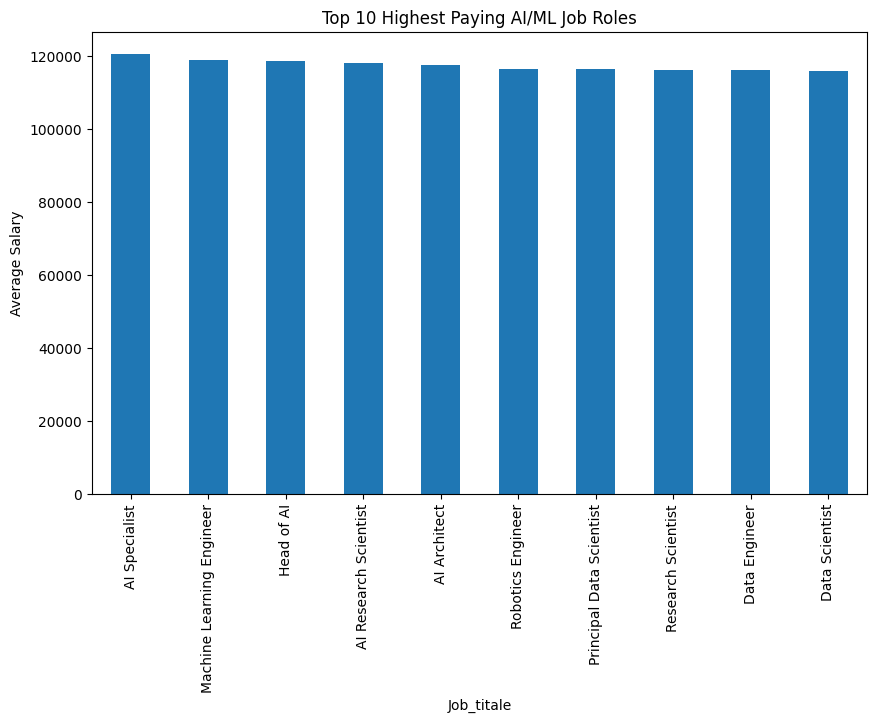

In [28]:
plt.figure(figsize=(10,6))
avg_salary.head(10).plot(kind="bar")
plt.title("Top 10 Highest Paying AI/ML Job Roles")
plt.xlabel("Job_titale")
plt.ylabel("Average Salary")
plt.xticks(rotation=90)
plt.show()

**3.How does salary change with experience?**

In [31]:
experience_salary=df.groupby("years_experience")["salary_usd"].mean()
experience_salary.head()

years_experience
0    63112.280952
1    63155.188731
2    88824.163842
3    87116.170810
4    87932.536680
Name: salary_usd, dtype: float64

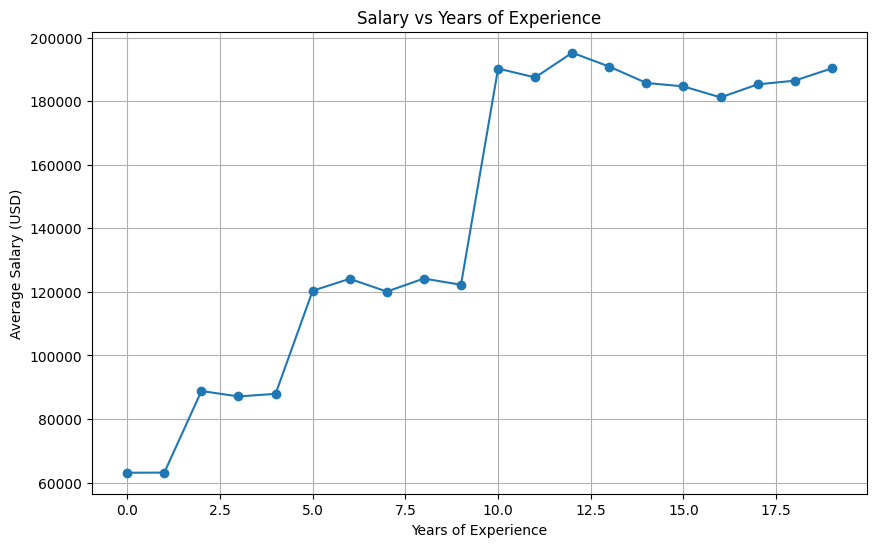

In [32]:
plt.figure(figsize=(10,6))
plt.plot(
    experience_salary.index,
    experience_salary.values,
    marker="o")

plt.title("Salary vs Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Average Salary (USD)")
plt.grid()
plt.show()

**4.Does education level affect salary?**

In [34]:
education_salary = (df.groupby("education_required")["salary_usd"].mean().sort_values(ascending=False))
education_salary

education_required
Master       117171.815902
Bachelor     115861.629190
Associate    114605.708058
PhD          113728.165579
Name: salary_usd, dtype: float64

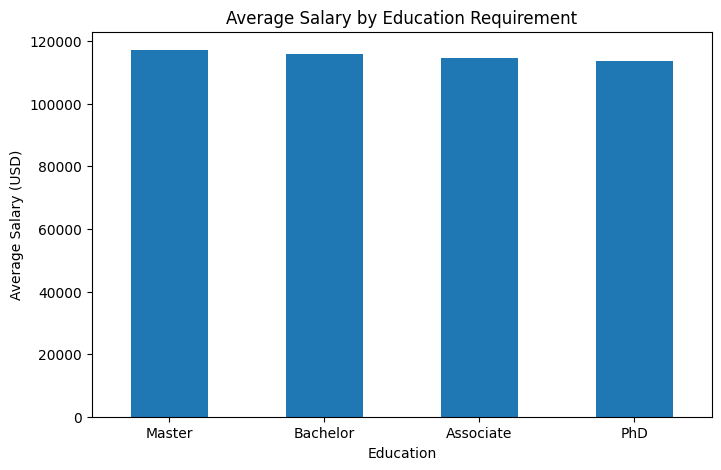

In [35]:
plt.figure(figsize=(8,5))
education_salary.plot(kind="bar")
plt.title("Average Salary by Education Requirement")
plt.xlabel("Education")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=0)
plt.show()

**5.Which countries have the highest job demand?**

In [36]:
country_demand = df["company_location"].value_counts()
country_demand.head(10)

company_location
Germany      814
Denmark      778
France       769
Canada       769
Austria      765
Singapore    764
China        763
India        754
Sweden       752
Israel       751
Name: count, dtype: int64

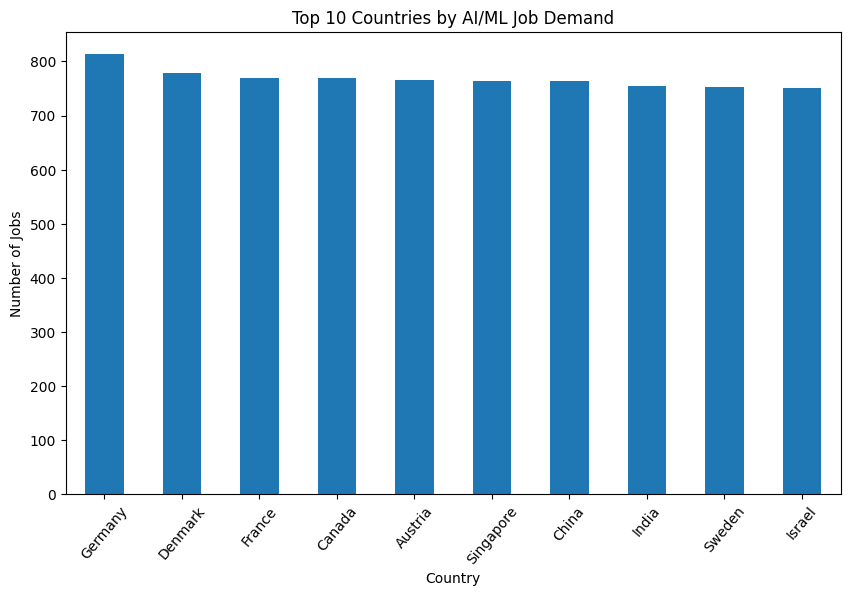

In [38]:
plt.figure(figsize=(10,6))
country_demand.head(10).plot(kind="bar")
plt.title("Top 10 Countries by AI/ML Job Demand")
plt.xlabel("Country")
plt.ylabel("Number of Jobs")
plt.xticks(rotation=50)
plt.show()

**6.Which countries offer the highest average salary?**

In [42]:
country_salary =(df.groupby("company_location")["salary_usd"].mean().sort_values(ascending=False))
country_salary.head(10)

company_location
Switzerland       170639.085791
Denmark           165652.249357
Norway            159490.533981
United States     146833.045580
United Kingdom    128720.186557
Singapore         128004.035340
Netherlands       126750.451436
Sweden            123559.753989
Germany           121810.143735
Australia         118238.887978
Name: salary_usd, dtype: float64

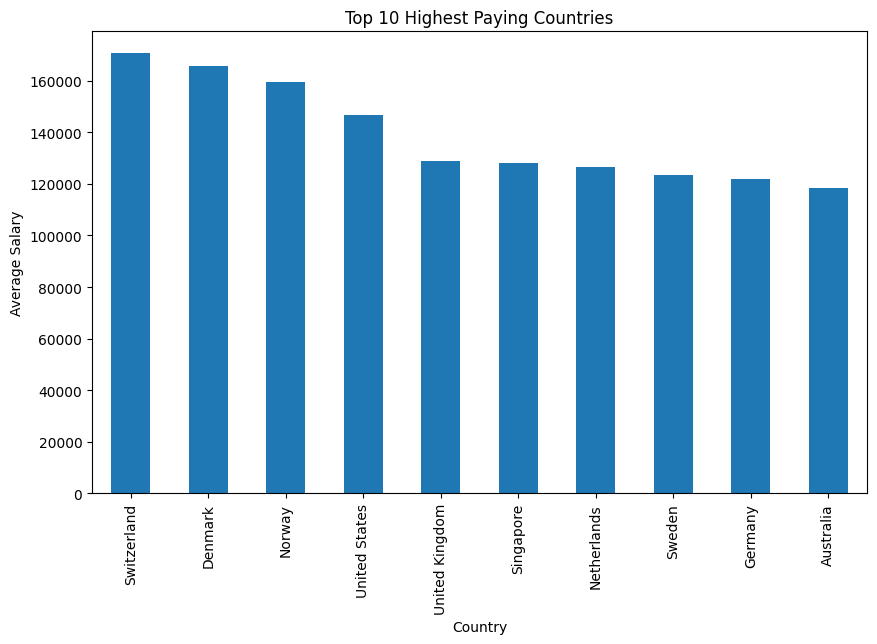

In [43]:
plt.figure(figsize=(10,6))
country_salary.head(10).plot(kind="bar")
plt.title("Top 10 Highest Paying Countries")
plt.xlabel("Country")
plt.ylabel("Average Salary")
plt.xticks(rotation=90)
plt.show()

**7.Does remote work affect salary?**

In [44]:
df["remote_type"] = df["remote_ratio"].map({
    0: "On-site",
    50: "Hybrid",
    100: "Fully Remote"})

In [45]:
remote_salary = (
    df.groupby("remote_type")["salary_usd"]
    .mean()
    .sort_values(ascending=False)
)

remote_salary

remote_type
Fully Remote    116160.545935
Hybrid          115776.806793
On-site         114140.231133
Name: salary_usd, dtype: float64

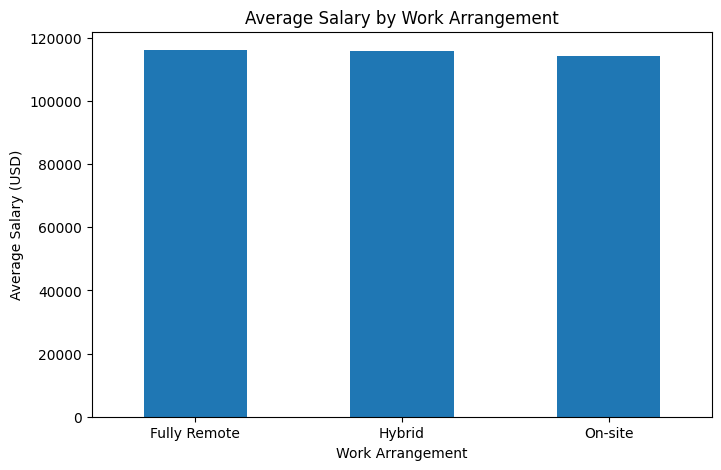

In [46]:
plt.figure(figsize=(8,5))
remote_salary.plot(kind="bar")
plt.title("Average Salary by Work Arrangement")
plt.xlabel("Work Arrangement")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=0)
plt.show()

**8.Which industries have the highest job demand?**

In [47]:
industry_demand = df["industry"].value_counts()
industry_demand

industry
Retail                1063
Media                 1045
Automotive            1020
Consulting            1020
Technology            1011
Real Estate           1007
Government             998
Healthcare             997
Telecommunications     997
Transportation         997
Finance                984
Energy                 976
Gaming                 967
Manufacturing          962
Education              956
Name: count, dtype: int64

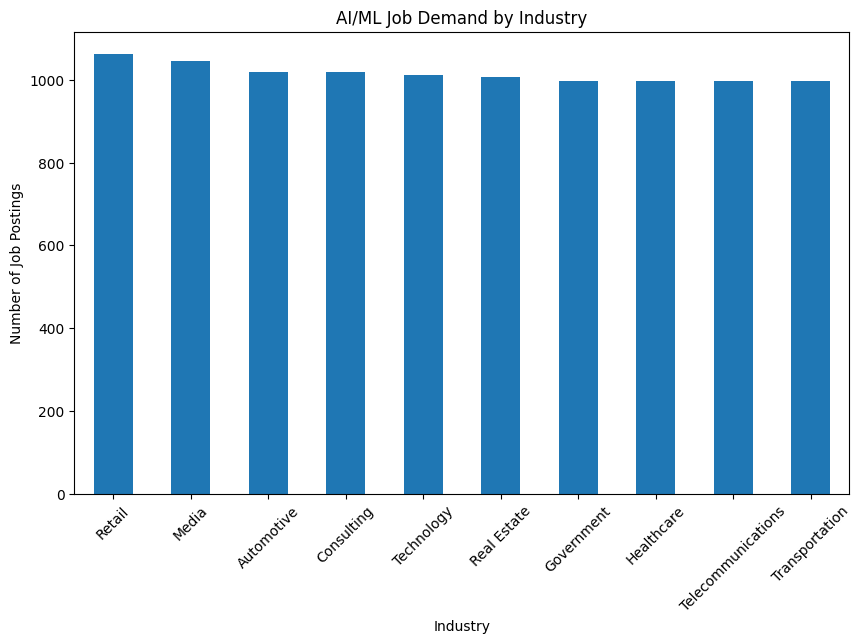

In [48]:
plt.figure(figsize=(10,6))
industry_demand.head(10).plot(kind="bar")
plt.title("AI/ML Job Demand by Industry")
plt.xlabel("Industry")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.show()

**9.Which industries pay the highest salaries?**

In [54]:
industry_salary = (df.groupby("industry")["salary_usd"].mean().sort_values(ascending=False))
industry_salary

industry
Consulting            117602.142157
Manufacturing         116162.888773
Media                 116127.730144
Education             116026.803347
Real Estate           115919.095333
Technology            115831.823937
Government            115694.321643
Finance               115323.398374
Telecommunications    115291.411234
Energy                115188.436475
Transportation        114837.802407
Retail                114776.363123
Healthcare            114433.883651
Automotive            113987.241176
Gaming                112979.574974
Name: salary_usd, dtype: float64

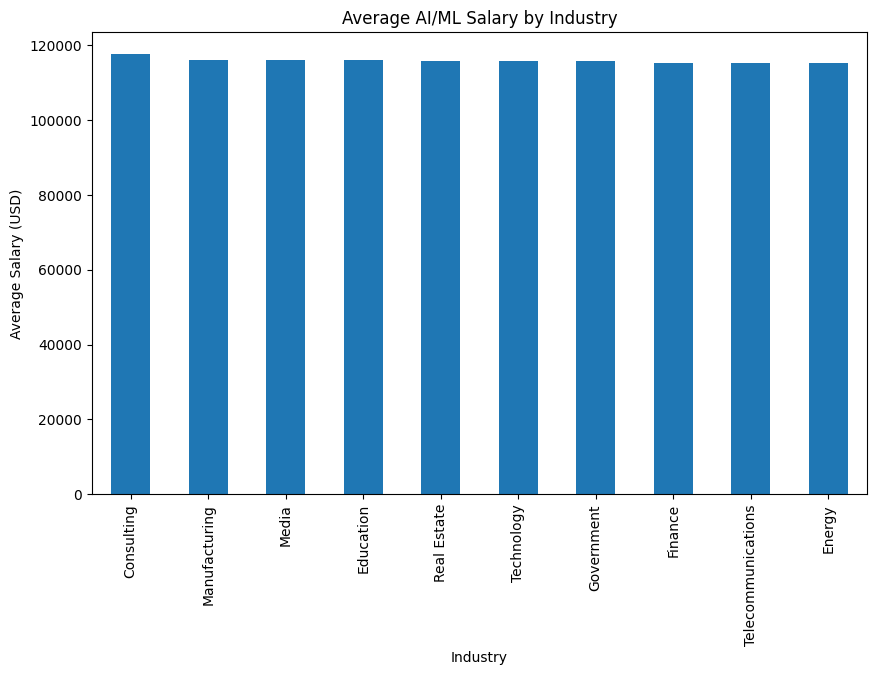

In [55]:
plt.figure(figsize=(10,6))
industry_salary.head(10).plot(kind="bar")
plt.title("Average AI/ML Salary by Industry")
plt.xlabel("Industry")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=90)
plt.show()

**10.Does company size affect salary?**

In [56]:
company_size_salary = (df.groupby("company_size")["salary_usd"].mean().sort_values(ascending=False))
company_size_salary

company_size
L    130322.451781
M    113600.237037
S    102146.930098
Name: salary_usd, dtype: float64

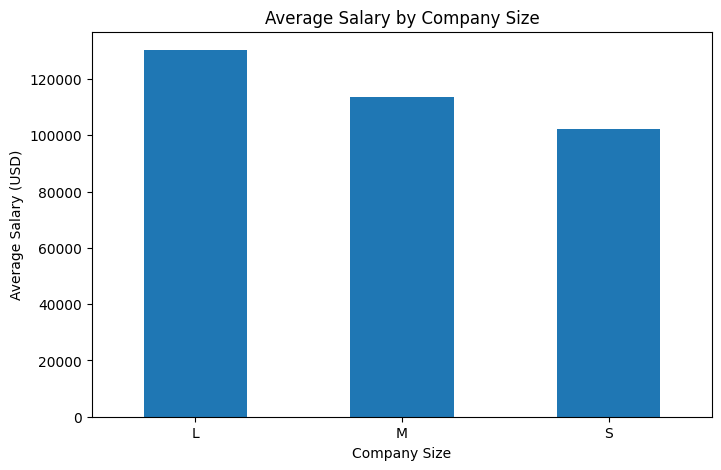

In [57]:
plt.figure(figsize=(8,5))
company_size_salary.plot(kind="bar")
plt.title("Average Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=0)
plt.show()

In [58]:
corr = df.corr(numeric_only=True)
corr

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
salary_usd,1.000000,0.013727,0.737556,-0.009092,0.000985
remote_ratio,0.013727,1.000000,0.015321,0.004475,0.003139
years_experience,0.737556,0.015321,1.000000,-0.007526,-0.007275
job_description_length,-0.009092,0.004475,-0.007526,1.000000,0.006744
benefits_score,0.000985,0.003139,-0.007275,0.006744,1.000000


# Heatmap

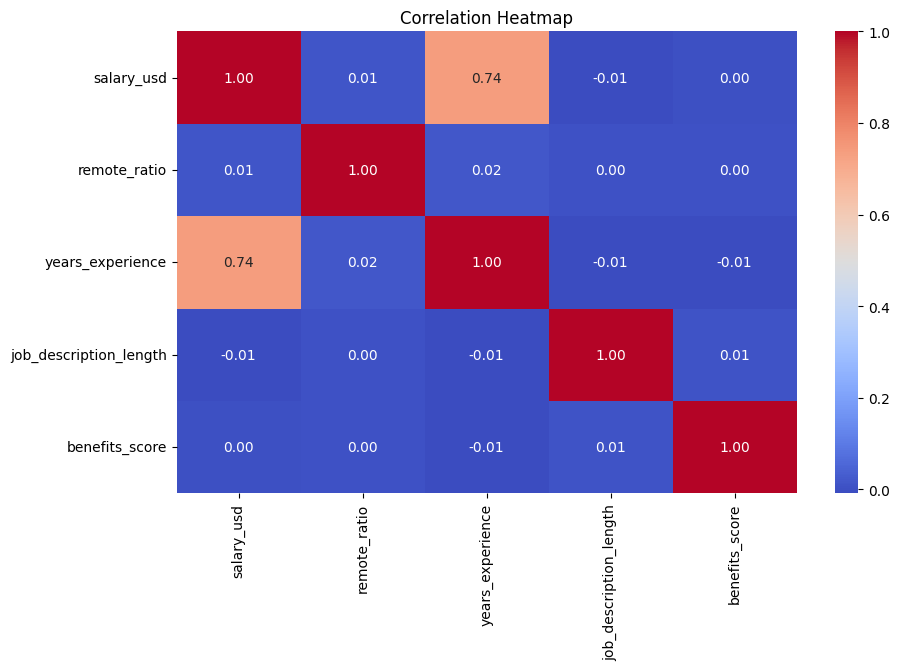

In [59]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Salary correlations only

In [60]:
corr["salary_usd"].sort_values(ascending=False)

salary_usd                1.000000
years_experience          0.737556
remote_ratio              0.013727
benefits_score            0.000985
job_description_length   -0.009092
Name: salary_usd, dtype: float64

In [22]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


# Select Features

In [93]:
features = [
    "years_experience",
    "remote_ratio",
    "job_description_length",
    "benefits_score"]

X = df[features]
y = df["salary_usd"]

# Check X and y

In [94]:
X.head()

,years_experience,remote_ratio,job_description_length,benefits_score
0,9,50,1076,5.9
1,1,100,1268,5.2
2,2,0,1974,9.4
3,7,50,1345,8.6
4,0,100,1989,6.6


In [95]:
y.head()

0     90376
1     61895
2    152626
3     80215
4     54624
Name: salary_usd, dtype: int64

# Train-Test Split

In [96]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.2,random_state=42)

In [97]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3000, 4)
X_test : (12000, 4)
y_train: (3000,)
y_test : (12000,)


# Feature Scaling

In [98]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Convert back to DataFrame for viewing:

In [99]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=features,index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=features,index=X_test.index)

In [100]:
X_train_scaled.head()

,years_experience,remote_ratio,job_description_length,benefits_score
9223,0.151771,0.016211,0.790048,0.348874
12101,-0.212479,-1.199610,-0.060072,-0.550999
6230,-0.576729,0.016211,-1.134917,1.041083
13366,-0.030354,1.232032,-1.178468,0.694979
12506,-1.123103,0.016211,0.295306,-0.689441


# Create KNN Regression Model

In [101]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


# Prediction

In [102]:
y_pred=knn.predict(X_test_scaled)
print(y_pred[:10])

[134303.8 173034.2 122959.  134986.6  66075.4 102107.2  55852.2  59858.4
 144265.   82019.4]


# Evaluation Metrics

**MAE**

In [109]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae=mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 31332.279683333327


**MSE**

In [110]:
mse=mean_squared_error(y_test,y_pred)
print("MSE:",mse)

MSE: 1813260163.0716233


**RMSE**

In [113]:
rmse=np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 42582.39264146184


**R² Score**

In [114]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.49778817090434524


# Actual vs Predicted

In [115]:
results = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})

results.head(10)

,Actual Salary,Predicted Salary
0,138919,134303.8
1,187208,173034.2
2,158264,122959.0
3,139174,134986.6
4,61622,66075.4
5,90518,102107.2
6,84245,55852.2
7,51038,59858.4
8,105093,144265.0
9,54155,82019.4


# Actual vs Predicted Graph

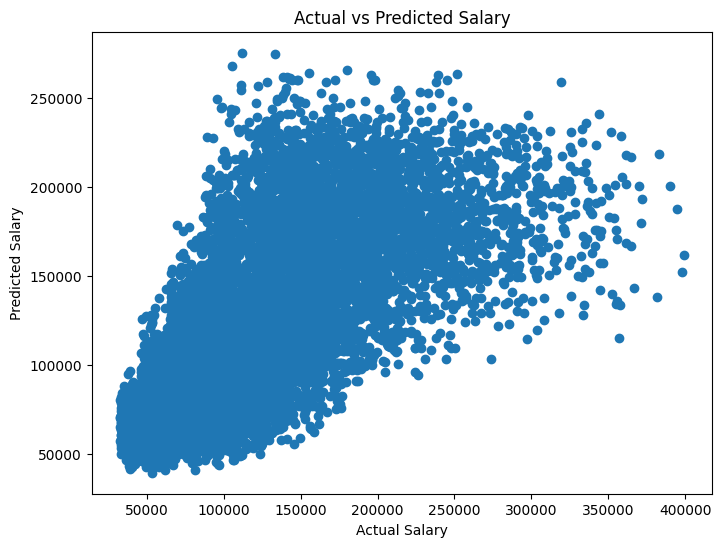

In [116]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

# Find Best K

In [117]:
k_values = range(1, 21)
rmse_values = []
for k in k_values:
    
    model = KNeighborsRegressor(n_neighbors=k)
    
    model.fit(X_train_scaled, y_train)
    
    prediction = model.predict(X_test_scaled)
    
    rmse = np.sqrt(
        mean_squared_error(y_test, prediction)
    )
    
    rmse_values.append(rmse)

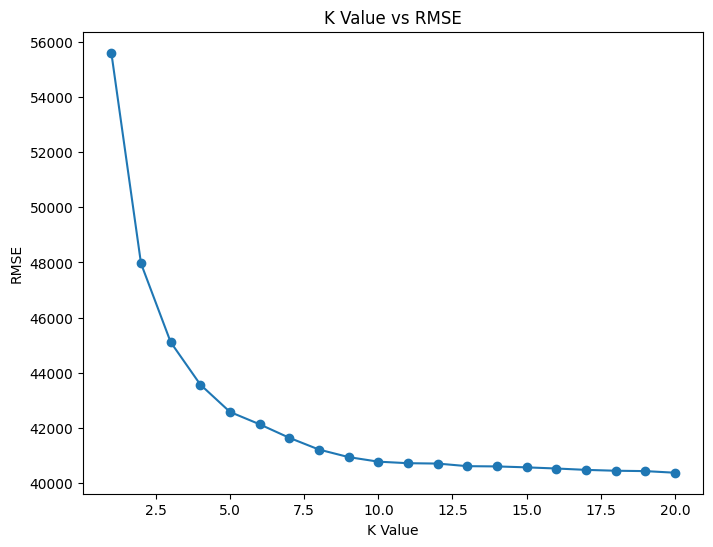

In [118]:
plt.figure(figsize=(8, 6))
plt.plot(k_values, rmse_values, marker="o")
plt.xlabel("K Value")
plt.ylabel("RMSE")
plt.title("K Value vs RMSE")
plt.show()

In [119]:
best_k = k_values[np.argmin(rmse_values)]
print("Best K:", best_k)

Best K: 20


# Final KNN Model

In [120]:
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",20
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [121]:
final_pred = final_model.predict(X_test_scaled)

In [122]:
final_mae = mean_absolute_error(y_test, final_pred)
final_mse = mean_squared_error(y_test, final_pred)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_pred)
print("Final MAE :", final_mae)
print("Final MSE  :", final_mse)
print("Final RMSE :", final_rmse)
print("Final R2   :", final_r2)

Final MAE : 29778.423824999998
Final MSE  : 1630512897.6129622
Final RMSE : 40379.60992398221
Final R2   : 0.5484029918315053


# Conclusion:
The KNN Regression model was used to predict AI job salaries based on factors such as years of experience, remote ratio, job description length, and benefits score.
The project shows that KNN Regression can be used to estimate job salaries by comparing similar job records. This model can help job seekers and companies understand expected salary levels.